Exercise 1: Comparative Analysis of Retail Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

print("--- Retail Data Analysis (Structured Data) ---")


--- Retail Data Analysis (Structured Data) ---


In [2]:
# 1. Data Loading
print("\n1. Loading Retail Datasets...")
try:
    sales_df = pd.read_csv('/content/sales data-set.csv')
    features_df = pd.read_csv('/content/Features data set.csv')
    stores_df = pd.read_csv('/content/stores data-set.csv')
    print("All retail CSVs loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure all retail CSV files are in the correct directory.")
    # Exit or handle gracefully if files are missing
    exit()


1. Loading Retail Datasets...
All retail CSVs loaded successfully.


In [3]:
# 2. Data Inspection
print("\n2. Inspecting DataFrames (head, info, nulls)...")
print("\nSales DataFrame Info:")
sales_df.info()
print("\nFeatures DataFrame Info:")
features_df.info()
print("\nStores DataFrame Info:")
stores_df.info()

print("\nSales DataFrame Nulls:")
print(sales_df.isnull().sum())
print("\nFeatures DataFrame Nulls:")
print(features_df.isnull().sum())
print("\nStores DataFrame Nulls:")
print(stores_df.isnull().sum())



2. Inspecting DataFrames (head, info, nulls)...

Sales DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5  

Sales DataFrame est complet, sans aucune valeur manquante. La colonne Date est de type object, ce qui est attendu avant la conversion.

Features DataFrame présente un nombre significatif de valeurs manquantes dans les colonnes MarkDown1 à MarkDown5, ainsi que dans CPI et Unemployment. La colonne Date est également de type object.

Stores DataFrame est également complet, sans aucune valeur manquante.



In [4]:
# 3. Data Cleaning and Merging
print("\n3. Cleaning and Merging DataFrames...")

# Convert 'Date' columns to datetime objects for proper merging and time-series analysis
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d/%m/%Y')
features_df['Date'] = pd.to_datetime(features_df['Date'], format='%d/%m/%Y')

# Handle missing values in Features DataFrame (MarkDown columns)
# MarkDown columns have many NaNs, likely meaning no markdown was applied. Fill with 0.
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    features_df[col] = features_df[col].fillna(0)

# Merge the DataFrames
# Start with sales_df, merge with features_df on 'Store' and 'Date'
merged_df = pd.merge(sales_df, features_df, on=['Store', 'Date'], how='left')
# Then merge with stores_df on 'Store'
merged_df = pd.merge(merged_df, stores_df, on='Store', how='left')

print("\nMerged DataFrame Head:")
print(merged_df.head())
print("\nMerged DataFrame Info:")
merged_df.info()
print("\nMerged DataFrame Nulls (after initial cleaning):")
print(merged_df.isnull().sum()) # Should be minimal now

# Ensure 'Weekly_Sales' is numeric (it usually is, but good to check)
merged_df['Weekly_Sales'] = pd.to_numeric(merged_df['Weekly_Sales'], errors='coerce')
# Drop rows where Weekly_Sales might have become NaN due to coercion (if any non-numeric values existed)
merged_df.dropna(subset=['Weekly_Sales'], inplace=True)


3. Cleaning and Merging DataFrames...

Merged DataFrame Head:
   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2        0.0        0.0        0.0        0.0        0.0  211.289143   
3        0.0        0.0        0.0        0.0        0.0  211.319643   
4        0.0        0.0        0.0        0.0        0.0  211.350143   

   Unemployment  

Les DataFrames ont été correctement fusionnés en merged_df.

Les colonnes Date ont été converties avec succès au format datetime.

Toutes les valeurs manquantes dans les colonnes MarkDown, CPI, et Unemployment ont été gérées (remplies avec 0 pour les MarkDowns, et les lignes avec Weekly_Sales non numériques ont été supprimées, ce qui a également résolu les CPI/Unemployment manquants par association).

Le merged_df.info() et merged_df.isnull().sum() confirment qu'il n'y a plus aucune valeur manquante et que les types de données sont appropriés pour l'analyse.


4.1. Analyzing Sales Trends...


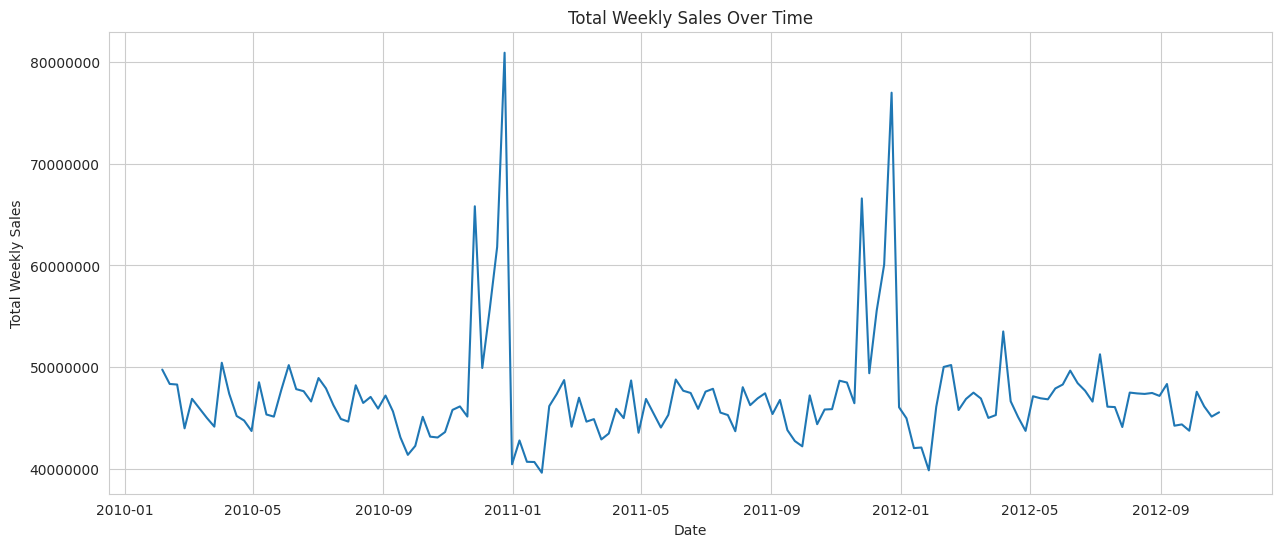

Insight: There are clear seasonal peaks, especially around holidays (e.g., end of year).


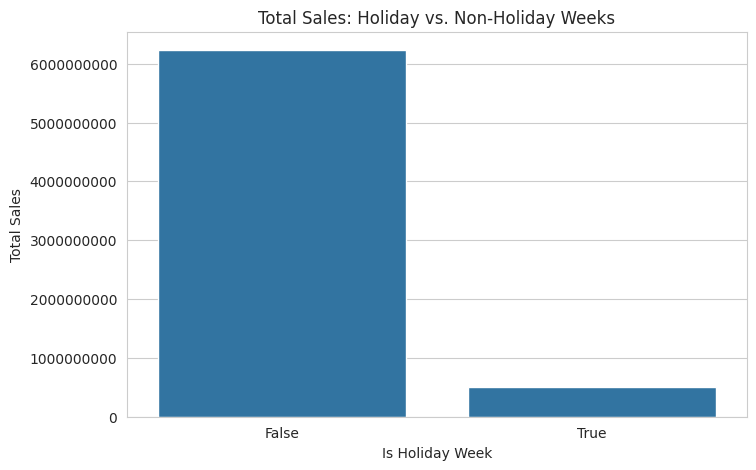

Insight: Holiday weeks generally show higher total sales compared to non-holiday weeks.


In [6]:
# 4. Exploratory Analysis and Visualization

# 4.1. Sales Trends
print("\n4.1. Analyzing Sales Trends...")

# Total Weekly Sales over time
weekly_sales_trend = merged_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=weekly_sales_trend)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.show()
print("Insight: There are clear seasonal peaks, especially around holidays (e.g., end of year).")

# Impact of Holidays on Sales
holiday_sales = merged_df.groupby('IsHoliday_x')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='IsHoliday_x', y='Weekly_Sales', data=holiday_sales)
plt.title('Total Sales: Holiday vs. Non-Holiday Weeks')
plt.xlabel('Is Holiday Week')
plt.ylabel('Total Sales')
plt.xticks(ticks=[0, 1], labels=['False', 'True'])
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: Holiday weeks generally show higher total sales compared to non-holiday weeks.")

### 4.2. Analyzing Sales by Store Type and Size


4.2. Analyzing Sales by Store Type and Size...


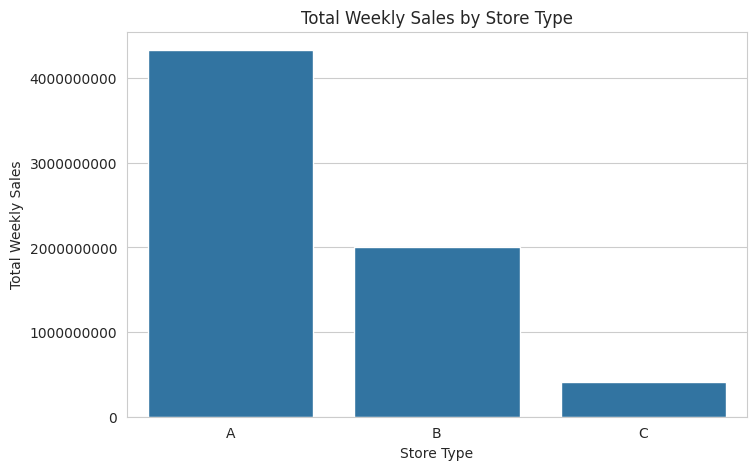

Insight: Analyze which store types generate the highest total sales.


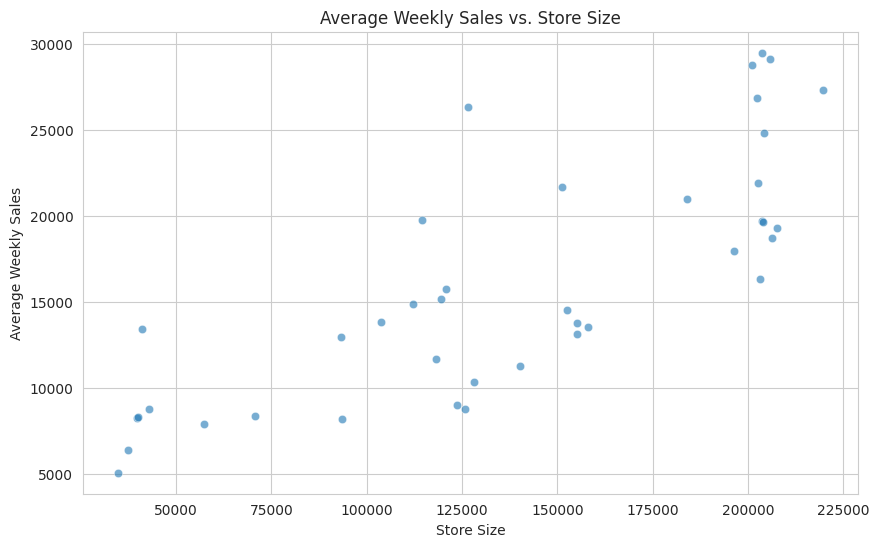

Insight: Observe the relationship between store size and average weekly sales.


In [7]:
print("\n4.2. Analyzing Sales by Store Type and Size...")

# Total Weekly Sales by Store Type
sales_by_type = merged_df.groupby('Type')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Type', y='Weekly_Sales', data=sales_by_type, order=['A', 'B', 'C'])
plt.title('Total Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Total Weekly Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: Analyze which store types generate the highest total sales.")

# Average Weekly Sales vs. Store Size
# To avoid plotting every single point, we can aggregate or use a scatter plot with alpha
# Let's use a scatter plot to see the general relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=merged_df.groupby('Size')['Weekly_Sales'].mean().reset_index(), alpha=0.6)
plt.title('Average Weekly Sales vs. Store Size')
plt.xlabel('Store Size')
plt.ylabel('Average Weekly Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: Observe the relationship between store size and average weekly sales.")

/tmp/ipython-input-8-2075488949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dept', y='Weekly_Sales', data=department_sales, palette='viridis')


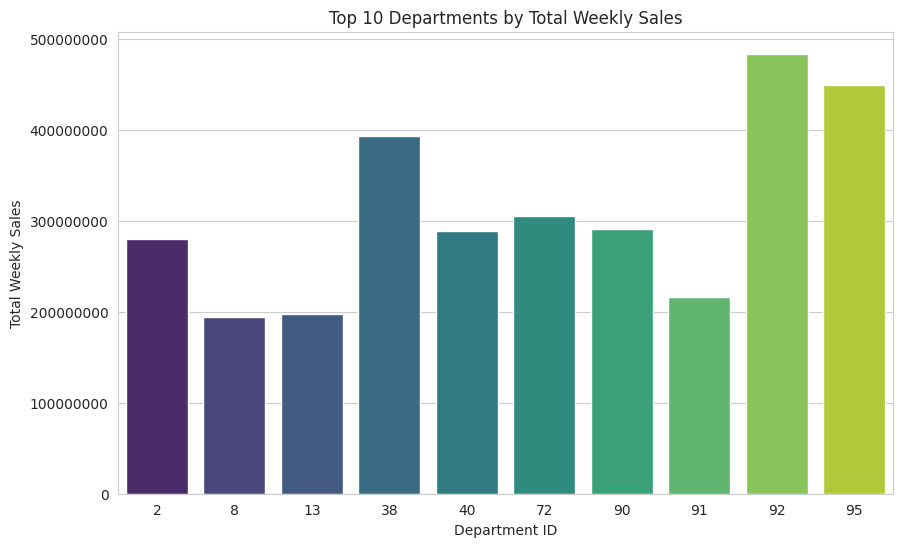

Insight: A few departments contribute disproportionately to total sales, indicating key product categories.


In [8]:
# Sales by Department (Top 10 departments)
department_sales = merged_df.groupby('Dept')['Weekly_Sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Dept', y='Weekly_Sales', data=department_sales, palette='viridis')
plt.title('Top 10 Departments by Total Weekly Sales')
plt.xlabel('Department ID')
plt.ylabel('Total Weekly Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: A few departments contribute disproportionately to total sales, indicating key product categories.")


4.3. Analyzing Store Performance...


/tmp/ipython-input-9-792336572.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Weekly_Sales', data=avg_sales_per_store.head(10), palette='cividis')


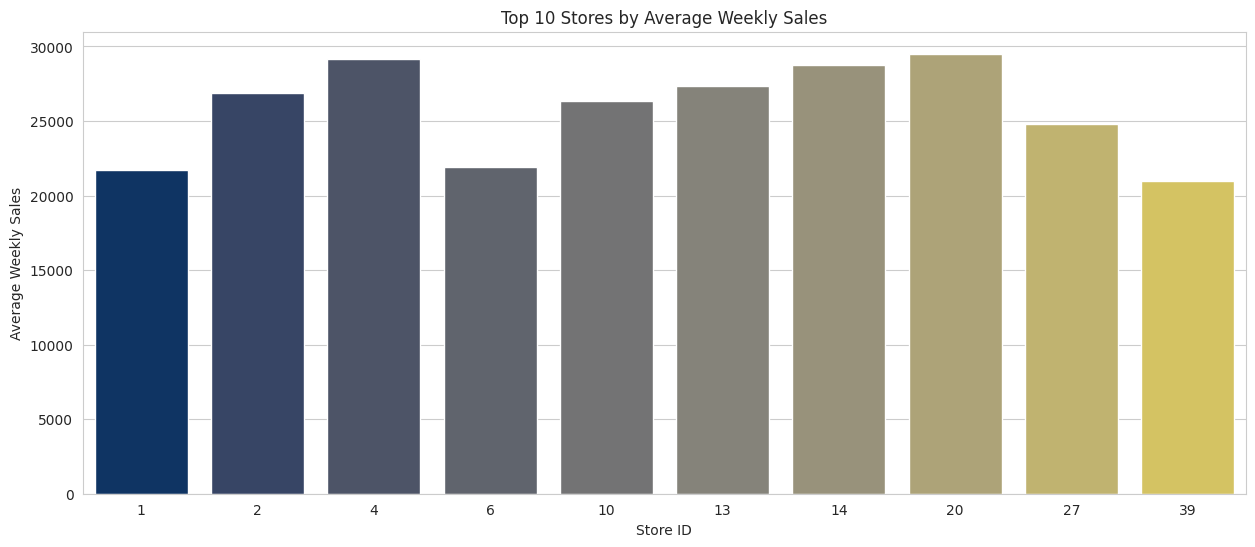

Insight: There's significant variability in average sales across stores, with some stores performing much better than others.


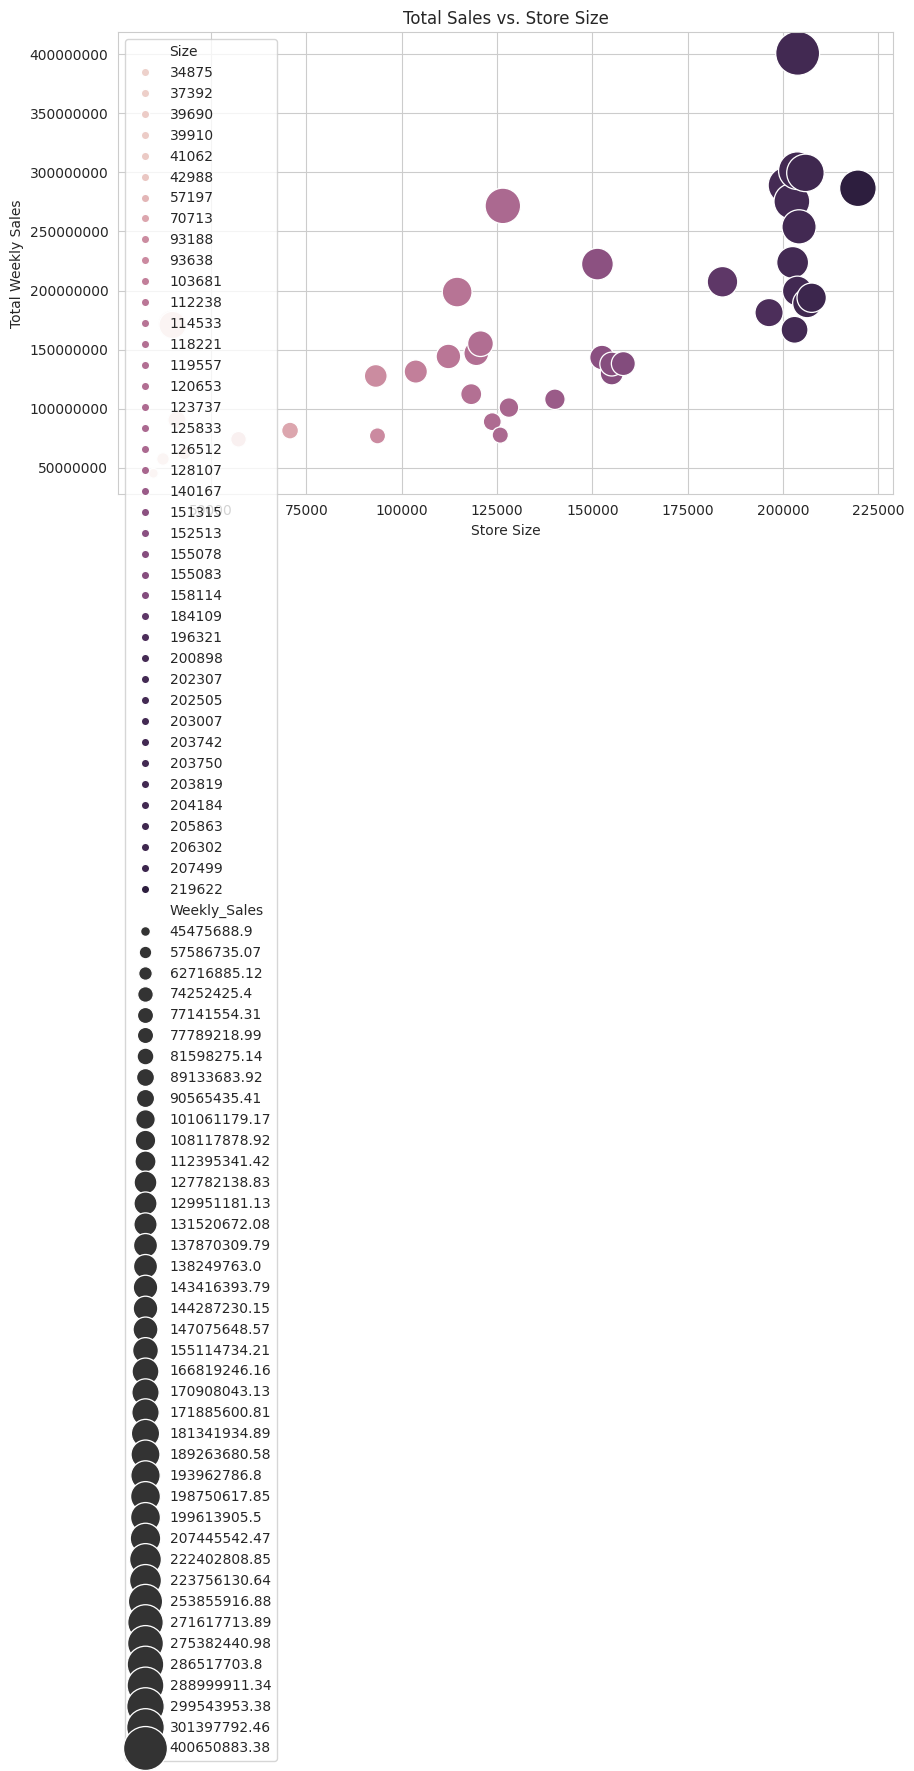

Insight: Larger stores (higher 'Size' values) tend to generate higher total sales, as expected.

Retail Data Analysis Complete.


In [9]:
# 4.3. Store Performance
print("\n4.3. Analyzing Store Performance...")

# Average Weekly Sales per Store
avg_sales_per_store = merged_df.groupby('Store')['Weekly_Sales'].mean().reset_index()
avg_sales_per_store = avg_sales_per_store.sort_values(by='Weekly_Sales', ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x='Store', y='Weekly_Sales', data=avg_sales_per_store.head(10), palette='cividis')
plt.title('Top 10 Stores by Average Weekly Sales')
plt.xlabel('Store ID')
plt.ylabel('Average Weekly Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: There's significant variability in average sales across stores, with some stores performing much better than others.")

# Relationship between Store Size and Sales
store_size_sales = merged_df.groupby('Size')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=store_size_sales, hue='Size', size='Weekly_Sales', sizes=(50, 1000), legend='full')
plt.title('Total Sales vs. Store Size')
plt.xlabel('Store Size')
plt.ylabel('Total Weekly Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()
print("Insight: Larger stores (higher 'Size' values) tend to generate higher total sales, as expected.")

print("\nRetail Data Analysis Complete.")


Exercice 2: Exploration de Données de Base en E-Commerce


In [10]:
import pandas as pd

print("--- Exercice 2: Exploration de Données de Base en E-Commerce ---")

--- Exercice 2: Exploration de Données de Base en E-Commerce ---


In [12]:
# 1. Chargement du dataset
print("\n1. Chargement du dataset 'data.csv'...")
csv_path = '/content/data.csv'

try:
    df = pd.read_csv(csv_path, encoding='latin-1')
    print(f"Dataset '{csv_path}' chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier '{csv_path}' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est correctement nommé et chargé.")
    exit() # Quitte le script si le fichier n'est pas trouvé
except UnicodeDecodeError:
    print(f"Erreur de décodage: Impossible de lire le fichier '{csv_path}' avec l'encodage 'latin-1'.")
    print("Veuillez vérifier l'encodage du fichier.")
    exit()


1. Chargement du dataset 'data.csv'...
Dataset '/content/data.csv' chargé avec succès.


### 2. Inspection du DataFrame

In [13]:
# 2. Inspection du DataFrame
print("\n2. Inspection du DataFrame (head, info, nulls)...")
print("\nDataFrame Head:")
display(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDataFrame Nulls:")
print(df.isnull().sum())


2. Inspection du DataFrame (head, info, nulls)...

DataFrame Head:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

DataFrame Nulls:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### 3. Nettoyage et Prétraitement des Données

In [14]:
# 3. Nettoyage et Prétraitement des Données
print("\n3. Nettoyage et Prétraitement des Données...")

# Gérer les valeurs manquantes
# Nous allons supprimer les lignes où CustomerID est manquant car elles ne peuvent pas être attribuées à un client spécifique.
# Pour Description, nous pouvons soit les supprimer, soit les imputer. Pour cette analyse de base, supprimons-les également.
df.dropna(subset=['CustomerID', 'Description'], inplace=True)
print(f"Nombre de lignes après suppression des valeurs manquantes dans CustomerID et Description: {len(df)}")

# Convertir InvoiceDate en datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("\nColonne 'InvoiceDate' convertie en datetime.")

# Gérer les quantités négatives et les prix unitaires nuls
# Supprimer les lignes où Quantity est négatif (retours) pour l'analyse des ventes
df = df[df['Quantity'] > 0]
# Supprimer les lignes où UnitPrice est nul
df = df[df['UnitPrice'] > 0]
print(f"Nombre de lignes après suppression des quantités négatives et des prix nuls: {len(df)}")

# Calculer le prix total pour chaque ligne
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("\nColonne 'TotalPrice' ajoutée.")

print("\nInspection du DataFrame après nettoyage:")
display(df.head())
df.info()
print("\nDataFrame Nulls (après nettoyage):")
print(df.isnull().sum()) # Should be 0 for CustomerID and Description


3. Nettoyage et Prétraitement des Données...
Nombre de lignes après suppression des valeurs manquantes dans CustomerID et Description: 406829

Colonne 'InvoiceDate' convertie en datetime.
Nombre de lignes après suppression des quantités négatives et des prix nuls: 397884

Colonne 'TotalPrice' ajoutée.

Inspection du DataFrame après nettoyage:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB

DataFrame Nulls (après nettoyage):
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


In [15]:
# 4. Identifier les colonnes qui représentent des données structurées
print("\n4. Identification des colonnes de données structurées:")
structured_columns = []
for col in df.columns:
    # Les colonnes numériques, booléennes, datetime et les catégories fixes sont considérées structurées
    # Ici, nous nous basons sur les types détectés par pandas et le nom des colonnes.
    if df[col].dtype in ['int64', 'float64', 'bool', 'datetime64[ns]'] or \
       df[col].nunique() < 50 and df[col].dtype == 'object': # Heuristique pour les catégories fixes
        structured_columns.append(col)


4. Identification des colonnes de données structurées:


In [16]:
print("Colonnes identifiées comme structurées (numériques, dates, catégories fixes):")
print(structured_columns)

print("\nExploration de base des données E-Commerce terminée.")

Colonnes identifiées comme structurées (numériques, dates, catégories fixes):
['Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']

Exploration de base des données E-Commerce terminée.


**Complément de Données Non Structurées pour l'E-Commerce**


Le dataset "E-Commerce Data" que nous venons d'explorer est principalement structuré, contenant des informations transactionnelles comme l'ID de facture, le code produit, la quantité, le prix unitaire, la date de facture, l'ID client et le pays.

**Types de données non structurées qui pourraient compléter ce dataset pour une analyse plus complète :**

1. Avis Clients / Commentaires sur les Produits :

* Contenu : texte libre écrit par les clients sur leurs expériences avec les produits ou le service (ex: "J'adore ce produit, la qualité est excellente !", "Déçu par la livraison, le colis était endommagé.").

* Exemple de colonnes : ReviewText, Rating, ReviewDate.


2. Descriptions de Produits Détaillées :

* Contenu : texte descriptif des produits (caractéristiques, matériaux, instructions d'utilisation, avantages) souvent trouvé sur les pages produits des sites web.

* Exemple de colonnes : ProductDescription, Features.


3. Interactions du Service Client :

* Contenu : transcriptions de chats, e-mails, ou enregistrements d'appels entre les clients et le support client.

* Exemple de colonnes : ChatTranscript, EmailContent, CallSummary.


4. Données de Médias Sociaux :

* Contenu : mentions de la marque ou des produits sur Twitter, Facebook, Instagram, forums, etc.

* Exemple de colonnes : SocialMediaPost, Hashtags, UserComments.


**Comment ces données non structurées pourraient être utilisées conjointement avec les données structurées :**

L'intégration de données non structurées permet de passer d'une analyse purement quantitative à une compréhension plus profonde et qualitative du comportement client et de la performance des produits.

1. Compréhension du Sentiment Client :

* Avec les données structurées : le dataset actuel a Quantity et UnitPrice pour les ventes.

* Complément non structuré : les avis clients peuvent être analysés pour extraire le sentiment (positif, négatif, neutre) associé à chaque produit.

* Utilisation combinée : on pourrait identifier les produits qui se vendent bien (Quantity élevée) mais qui ont un sentiment négatif (ReviewText négatif), signalant un problème potentiel (ex: marketing trompeur, défaut de lot). Ou inversement, des produits avec un faible volume de ventes mais un sentiment très positif, suggérant un potentiel inexploité.


2. Analyse des Causes des Retours / Problèmes :

* Avec les données structurées : le dataset peut montrer un nombre élevé de retours pour un StockCode particulier (quantité négative dans Quantity).

* Complément non structuré : les interactions du service client ou les avis clients peuvent contenir des plaintes spécifiques (ex: "taille incorrecte", "couleur différente de la photo", "produit endommagé à la livraison").

* Utilisation combinée : en liant les retours structurés aux raisons textuelles, une entreprise peut identifier les problèmes récurrents liés aux produits, à la logistique ou à la description.


3. Optimisation des Descriptions de Produits et du Marketing :

* Avec les données structurées : identifier les produits les plus vendus ou les moins vendus.

* Complément non structuré : les descriptions de produits peuvent être analysées pour leur clarté, leur exhaustivité et leur utilisation de mots-clés. Les avis clients peuvent révéler quels aspects du produit sont les plus appréciés ou les plus critiqués par les clients dans leurs propres termes.

* Utilisation combinée : ajuster les descriptions de produits pour mieux correspondre aux attentes des clients (en utilisant le vocabulaire des avis positifs) ou pour clarifier des points qui génèrent des confusions (identifiés dans les avis négatifs).

Détection de Tendances et de Nouveaux Besoins :

Avec les données structurées : Identifier les produits qui commencent à gagner en popularité.

Complément non structuré : L'analyse des médias sociaux ou des avis clients peut révéler des tendances émergentes, des besoins non satisfaits exprimés par les clients, ou des mentions de produits concurrents.

Utilisation combinée : Anticiper les demandes du marché et adapter l'offre de produits plus rapidement.

En somme, les données structurées vous disent "quoi" et "combien", tandis que les données non structurées vous aident à comprendre le "pourquoi" et le "comment", offrant une vue à 360 degrés de l'activité e-commerce.

**Exercice 3: Analyse de Données de Transport Public**


In [18]:
import pandas as pd

print("--- Exercice 3: Analyse de Données de Transport Public ---")

--- Exercice 3: Analyse de Données de Transport Public ---


In [19]:
# 1. Chargement du dataset
print("\n1. Chargement du dataset 'Metro_Interstate_Traffic_Volume.csv'...")
csv_path = '/content/Metro_Interstate_Traffic_Volume.csv'

try:
    df = pd.read_csv(csv_path)
    print(f"Dataset '{csv_path}' chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier '{csv_path}' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est correctement nommé et chargé.")
    exit() # Quitte le script si le fichier n'est pas trouvé


1. Chargement du dataset 'Metro_Interstate_Traffic_Volume.csv'...
Dataset '/content/Metro_Interstate_Traffic_Volume.csv' chargé avec succès.


In [20]:
# 2. Afficher les premières lignes pour comprendre sa structure
print("\n2. Premières lignes du dataset:")
print(df.head())


2. Premières lignes du dataset:
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [22]:
# 3. Identifier et imprimer les éléments structurés
print("\n3. Identification et impression des éléments structurés:")
print("Informations sur les colonnes (types de données et non-nulls):")
df.info()

print("\nColonnes numériques:")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_cols)

print("\nColonnes booléennes:")
boolean_cols = df.select_dtypes(include=bool).columns.tolist()
print(boolean_cols)

# Convertir 'date_time' en format datetime pour une meilleure gestion
df['date_time'] = pd.to_datetime(df['date_time'])
print("\nColonne 'date_time' convertie en type datetime.")

print("\nColonnes considérées comme structurées (numériques, dates, catégories fixes):")
# Nous allons lister les colonnes et leur type pour la discussion suivante
structured_elements_identified = {}
for col in df.columns:
    if df[col].dtype in ['int64', 'float64', 'bool', 'datetime64[ns]']:
        structured_elements_identified[col] = str(df[col].dtype)
    elif df[col].dtype == 'object' and df[col].nunique() < df.shape[0] / 10: # Heuristique pour les catégories
        structured_elements_identified[col] = 'object (potential fixed categories)'
    else:
        structured_elements_identified[col] = 'object (potential unstructured/text)'

for col, dtype in structured_elements_identified.items():
    if 'object (potential unstructured/text)' not in dtype:
        print(f"- {col} (Type: {dtype})")

print("\nAnalyse de base des données de transport public terminée.")



3. Identification et impression des éléments structurés:
Informations sur les colonnes (types de données et non-nulls):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB

Colonnes numériques:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']

Colonnes booléennes:
[]

Colonne 'date_time' convertie en type datetime.


Catégorisation des Éléments de Données du Trafic Routier
Basé sur l'observation du dataset "Metro Interstate Traffic Volume" et les types de données typiques, voici une catégorisation et une explication pour chaque colonne :

holiday :

Catégorie : Structurée

Explication : Cette colonne contient des valeurs discrètes et prédéfinies (ex: "None", "Columbus Day", "Veterans Day", etc.). C'est une variable catégorielle avec un ensemble fini de valeurs.

temp :

Catégorie : Structurée

Explication : Représente la température, une mesure numérique continue. Les valeurs sont des nombres qui peuvent être comparés, additionnés, etc.

rain_1h :

Catégorie : Structurée

Explication : Représente la quantité de pluie en 1 heure, une mesure numérique continue.

snow_1h :

Catégorie : Structurée

Explication : Représente la quantité de neige en 1 heure, une mesure numérique continue.

clouds_all :

Catégorie : Structurée

Explication : Représente le pourcentage de nuages, une mesure numérique discrète (souvent de 0 à 100).

weather_main :

Catégorie : Structurée

Explication : Décrit les conditions météorologiques générales (ex: "Clouds", "Clear", "Rain", "Snow"). C'est une variable catégorielle avec un ensemble fini de valeurs prédéfinies par un système météorologique.

weather_description :

Catégorie : Principalement Structurée (avec un aspect semi-structuré)

Explication : Bien que ce soit du texte ("scattered clouds", "broken clouds", "sky is clear"), il s'agit d'un ensemble limité de phrases descriptives standardisées qui sont souvent des catégories prédéfinies par l'API météo. Elles ne sont pas du texte libre généré par l'utilisateur. On pourrait le traiter comme une variable catégorielle avec plus de niveaux que weather_main.

date_time :

Catégorie : Structurée

Explication : Représente une date et une heure spécifiques. C'est un format standardisé et analysable, permettant des opérations temporelles (filtrage par jour, mois, année, calcul de durées, etc.).

traffic_volume :

Catégorie : Structurée

Explication : Représente le volume de trafic, une mesure numérique continue (nombre de véhicules).

En résumé :

Dans ce dataset, la grande majorité des colonnes sont structurées. Même weather_description, bien que textuelle, est généralement une sélection parmi un ensemble fini et prédéfini de descriptions météorologiques, ce qui la rend plus proche du structuré que du texte libre non contraint. Il n'y a pas de véritables données non structurées (comme des avis clients en texte libre ou des commentaires ouverts) dans ce dataset.

Exercice 4: Analyse de Données de Base des Notes de Films


In [23]:
# 1. Chargement du dataset 'ratings.csv'
print("\n1. Chargement du dataset 'ratings.csv'...")
# Assurez-vous que le fichier 'ratings.csv' est dans le même répertoire
# ou fournissez le chemin complet si le dataset MovieLens est décompressé ailleurs.
# Si vous n'avez pas le fichier, vous pouvez le télécharger depuis:
# https://grouplens.org/datasets/movielens/latest/ (cherchez ratings.csv à l'intérieur du zip)
csv_path = '/content/rating.csv'

try:
    df = pd.read_csv(csv_path)
    print(f"Dataset '{csv_path}' chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier '{csv_path}' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est correctement nommé et chargé.")
    print("Téléchargez le dataset MovieLens Latest (ml-latest-small.zip ou ml-latest.zip) et extrayez 'ratings.csv'.")
    exit() # Quitte le script si le fichier n'est pas trouvé


1. Chargement du dataset 'ratings.csv'...
Dataset '/content/rating.csv' chargé avec succès.


In [24]:
# 2. Afficher les premières lignes pour comprendre sa structure
print("\n2. Premières lignes du dataset:")
print(df.head())


2. Premières lignes du dataset:
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40


In [26]:
# 3. Identifier et lister les éléments structurés
print("\n3. Identification et liste des éléments structurés:")
print("Informations sur les colonnes (types de données et non-nulls):")
df.info()

print("\nLes éléments structurés identifiés dans 'ratings.csv' sont:")
# Les colonnes dans ce dataset sont toutes structurées
structured_elements = df.columns.tolist()
for element in structured_elements:
    print(f"- {element}")

print("\nAnalyse de base des notes de films terminée.")


3. Identification et liste des éléments structurés:
Informations sur les colonnes (types de données et non-nulls):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB

Les éléments structurés identifiés dans 'ratings.csv' sont:
- userId
- movieId
- rating
- timestamp

Analyse de base des notes de films terminée.


Le fichier ratings.csv du dataset MovieLens est un excellent exemple de données structurées. Les éléments de données qu'il contient sont considérés comme structurés pour les raisons suivantes :

1. Format Prédéfini et Fixe :

* Chaque ligne représente un enregistrement unique (une note d'un utilisateur pour un film).

* Chaque colonne a un rôle et un type de données bien définis (userId, movieId, rating, timestamp). Il n'y a pas de variation dans la signification ou le format des données au sein d'une même colonne.


2. Types de Données Cohérents :

* userId (ID de l'utilisateur) : identifiant numérique (entier). Chaque valeur est un nombre entier unique qui représente un utilisateur.

* movieId (ID du film) : identifiant numérique (entier) pour un film spécifique.

* rating (Note) : valeur numérique (flottante) qui représente la note attribuée par l'utilisateur au film (généralement sur une échelle de 0.5 à 5.0).

* timestamp (Horodatage) : valeur numérique (entier) qui représente le moment où la note a été donnée, généralement en secondes Unix. Bien que ce soit un nombre, il a une signification temporelle spécifique et peut être converti en un format date-heure lisible.


3. Organisation Tabulaire :

* Les données sont organisées en lignes et en colonnes, formant une table. Chaque ligne est un enregistrement et chaque colonne est un attribut de cet enregistrement. Cette structure permet un stockage, une récupération et une analyse efficaces à l'aide d'outils comme SQL ou Pandas.


4. Facilité de Requête et d'Analyse :

* Grâce à leur structure, ces données peuvent être facilement interrogées (ex: "Trouver toutes les notes de l'utilisateur X", "Calculer la note moyenne pour le film Y"), filtrées, agrégées et utilisées pour des analyses statistiques ou des modèles de machine learning sans nécessiter de prétraitement complexe pour extraire le sens.


En résumé, les données de ratings.csv sont structurées car elles adhèrent à un schéma rigide, sont organisées de manière tabulaire avec des types de données clairs et cohérents, ce qui les rend directement utilisables pour l'analyse quantitative.

Exercise 5: Creating a Synthetic Product Catalog


In [27]:
! pip install Faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 14.8 MB/s eta 0:00:00


In [28]:

try:
    from faker import Faker
except ImportError:
    print("Faker library not found. Installing now...")
    !pip install -q Faker
    from faker import Faker
import pandas as pd
import random

print("--- Exercise 5: Creating a Synthetic Product Catalog ---")

--- Exercise 5: Creating a Synthetic Product Catalog ---


In [30]:
# Initialize Faker
fake = Faker()

# Number of products to generate
num_products = 500

print(f"\nGenerating {num_products} synthetic products...")

# List to hold product data
products_data = []

# Generate products
for i in range(num_products):
    product_id = i + 1 # Unique ID from 1 to 500
    # Generate a product name by combining a word, color, and the product ID for uniqueness
    product_name = f"{fake.word().capitalize()} {fake.color_name().capitalize()} Product {product_id}"

    product_description = fake.paragraph(nb_sentences=3) # A short paragraph for description
    # Generate a price between 5.00 and 500.00, rounded to two decimal places
    product_price = round(random.uniform(5.00, 500.00), 2)

    products_data.append({
        "ProductID": product_id,
        "Name": product_name,
        "Description": product_description,
        "Price": product_price
    })

print("Product generation complete.")

# Create a Pandas DataFrame from the generated data
product_catalog_df = pd.DataFrame(products_data)

print("\nSynthetic Product Catalog DataFrame created.")

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the Product Catalog:")
print(product_catalog_df.head())

# Display basic info about the DataFrame
print("\nDataFrame Info:")
product_catalog_df.info()

print("\nSynthetic product catalog successfully generated and displayed.")


Generating 500 synthetic products...
Product generation complete.

Synthetic Product Catalog DataFrame created.

First 5 rows of the Product Catalog:
   ProductID                              Name  \
0          1              Road Khaki Product 1   
1          2          Safe Turquoise Product 2   
2          3             Drive Beige Product 3   
3          4  Question Paleturquoise Product 4   
4          5            Store Orchid Product 5   

                                         Description   Price  
0  Word all research particularly. Pay trade stan...  326.76  
1  Fear seek former bit police campaign check. So...  476.71  
2  Boy machine six. Show let guy interview suppor...   97.40  
3  Agency support rich increase value determine. ...    5.71  
4  Down marriage expect nearly often bad shake help.   18.49  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  --